**Loan Default Prediction System**

In [38]:
#Import necesassry libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [39]:
# Load the data
df = pd.read_csv('/content/Loan_default.csv.zip')

In [40]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [41]:
df.shape

(255347, 18)

In [42]:
df.isnull().sum().sum()

np.int64(0)

In [43]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


Object `default` not found.
Default rate: 11.6%


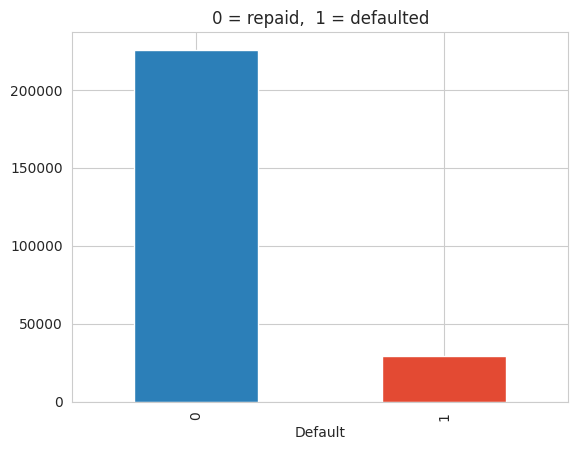

In [44]:
Target balance — what % actually default?
rate = df['Default'].mean()
print(f'Default rate: {rate:.1%}')
df['Default'].value_counts().plot(kind='bar', color=['#2c7fb8','#e34a33'])
plt.title('0 = repaid,  1 = defaulted'); plt.show()
# NOTE: only ~12% default. The data is imbalanced — keep an eye on F1, not just accuracy.

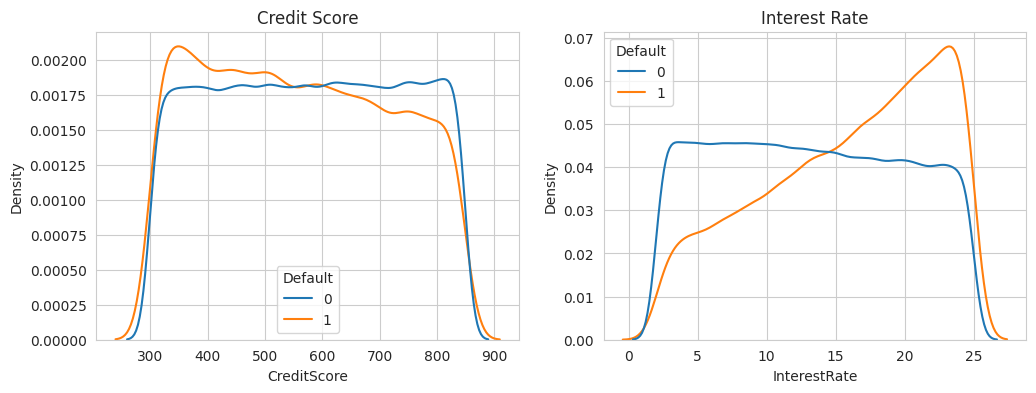

In [45]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.kdeplot(data=df, x='CreditScore', hue='Default', common_norm=False, ax=ax[0])
ax[0].set_title('Credit Score')
sns.kdeplot(data=df, x='InterestRate', hue='Default', common_norm=False, ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

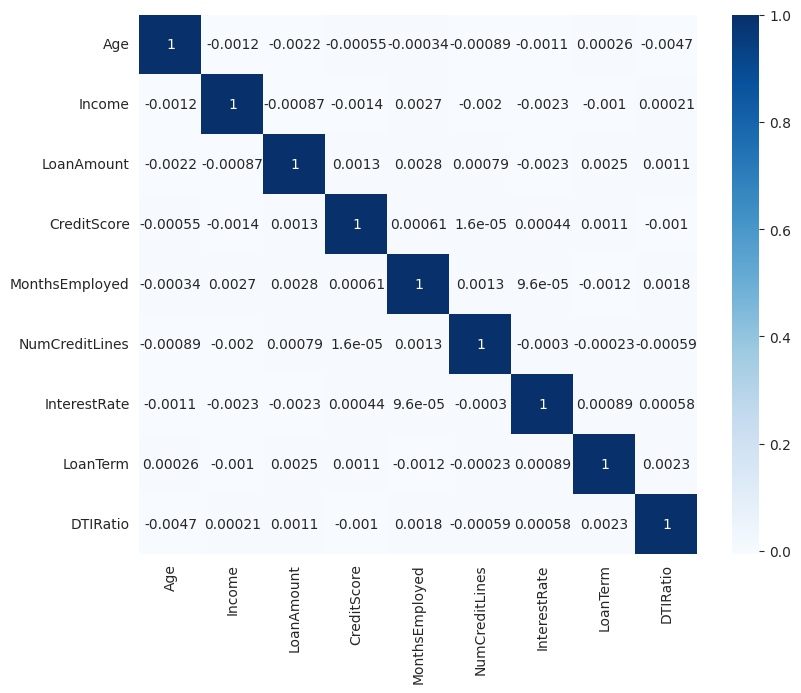

In [46]:
# correction
num = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
       'NumCreditLines','InterestRate','LoanTerm','DTIRatio']
plt.figure(figsize=(9,7))
sns.heatmap(df[num].corr(), annot=True, cmap='Blues')
plt.show()


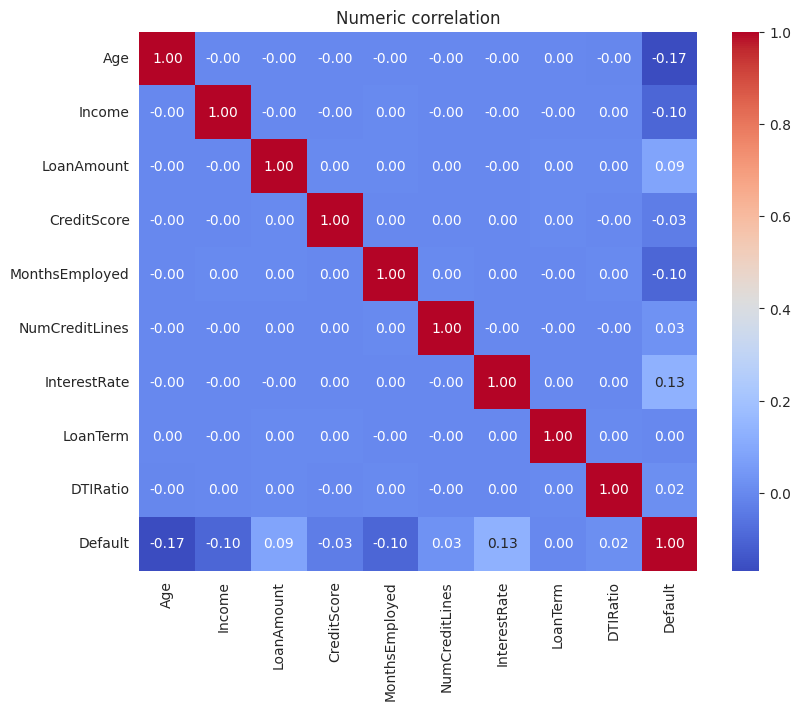

In [47]:
# correction
num = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
       'NumCreditLines','InterestRate','LoanTerm','DTIRatio']
plt.figure(figsize=(9,7))
sns.heatmap(df[num+['Default']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric correlation'); plt.show()

In [48]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


One-hot encoding

In [49]:
df_enc = pd.get_dummies(df.drop(columns=['LoanID']), drop_first=True)
df_enc = df_enc.dropna(subset=['Default']) # Drop rows where 'Default' is NaN
X = df_enc.drop(columns=['Default'])
y = df_enc['Default']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (204277, 24)  Test: (51070, 24)


MODEL BUILDING

**Logistic Regression**

In [50]:
# Train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1-Score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.8842
Logistic Regression F1-Score: 0.0117


Logistic Regression Feature Importance

In [51]:
feature_importance_log = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': log_reg_model.coef_[0]
})

feature_importance_log['absolute importance'] = abs(feature_importance_log['Importance'])
feature_importance_log = feature_importance_log.sort_values(by='absolute importance', ascending=False)
feature_importance_log.head(10)

,Feature,Importance,absolute importance
0,Age,-0.041584,0.041584
6,InterestRate,0.027900,0.027900
4,MonthsEmployed,-0.009515,0.009515
7,LoanTerm,0.002709,0.002709
5,NumCreditLines,0.000977,0.000977
23,HasCoSigner_Yes,-0.000766,0.000766
18,HasDependents_Yes,-0.000726,0.000726
14,EmploymentType_Unemployed,0.000547,0.000547
3,CreditScore,-0.000486,0.000486
17,HasMortgage_Yes,-0.000469,0.000469


Random Forest

In [52]:
rf_model = RandomForestClassifier(n_estimators=200,
                                  max_depth= 10,
                                  random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

In [53]:
#Evaluate the model
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

Random Forest Accuracy: 0.8845
Random Forest F1-Score: 0.0134


In [54]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf

,Feature,Importance
0,Age,0.226892
1,Income,0.188269
6,InterestRate,0.169212
2,LoanAmount,0.118471
4,MonthsEmployed,0.100475
3,CreditScore,0.049432
8,DTIRatio,0.034582
5,NumCreditLines,0.013601
7,LoanTerm,0.012341
23,HasCoSigner_Yes,0.011352


**XGBoost**




In [55]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

In [56]:
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

XGBoost Accuracy: 0.8867
XGBoost F1-Score: 0.1228


XGBOOST FEATURE IMPORTANCE

In [57]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)
feature_importance_xgb

,Feature,Importance
0,Age,0.167723
6,InterestRate,0.084499
1,Income,0.073590
2,LoanAmount,0.057224
4,MonthsEmployed,0.057111
18,HasDependents_Yes,0.056213
23,HasCoSigner_Yes,0.052832
14,EmploymentType_Unemployed,0.049794
13,EmploymentType_Self-employed,0.046117
15,MaritalStatus_Married,0.038502


COMPARE ALL THREE MODELS

In [58]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
    ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
    ]
})

comparison.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,F1 Score
2,XGBoost,0.886705,0.122802
1,Random Forest,0.884472,0.013378
0,Logistic Regression,0.884218,0.011700


VISUALIZE THE MODELS

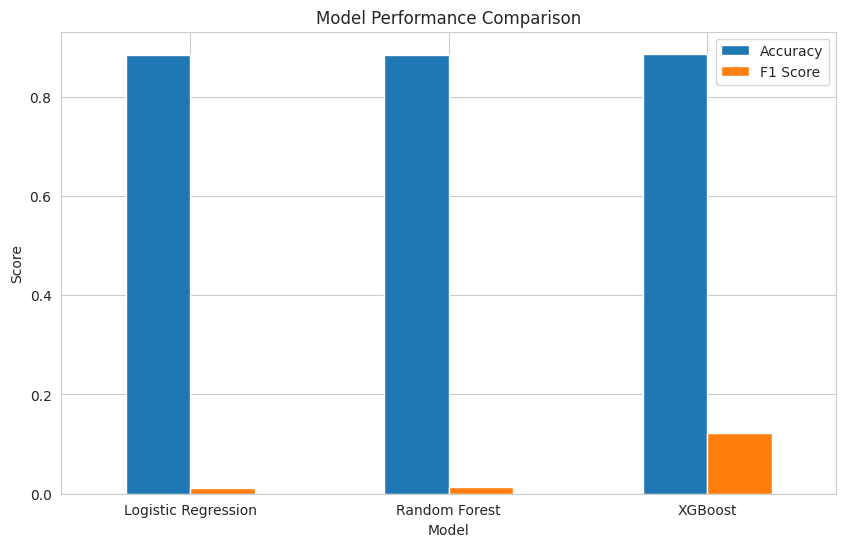

In [59]:
comparison.set_index('Model')[['Accuracy','F1 Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

SELECT THE BEST MODEL AUTOMATICALLY

In [60]:
best_model_name = comparison.sort_values(
by ='F1 Score',
ascending=False
).iloc[0]['Model']

print("Best Model: "), best_model_name

Best Model: 


(None, 'XGBoost')

SAVE MODEL

In [61]:
import joblib
if best_model_name == "Logistic Regression":
    best_model = log_reg_model

elif best_model_name == "Random Forest":
    best_model = rf_model

else:
    best_model = xgb_model

joblib.dump(best_model, "loan_default_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


STREAMLIT APPLICATION

app.py

In [62]:
app_py_content = """
import streamlit as st
import joblib
import pandas as pd

# PAGE CONFIGURATION

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💳",
    layout="wide"
)

# LOAD MODEL

model = joblib.load("loan_default_model.pkl")

# CUSTOM CSS

st.markdown('''
<style>

.main {
    background-color: #F8FAFC;
}

.title {
    text-align:center;
    color:#1E3A8A;
    font-size:45px;
    font-weight:700;
}

.subtitle {
    text-align:center;
    color:#64748B;
    font-size:18px;
}

.metric-card {
    background-color:white;
    padding:15px;
    border-radius:12px;
    box-shadow:0px 2px 10px rgba(0,0,0,0.08);
}

.stButton > button {
    width:100%;
    height:55px;
    border-radius:12px;
    font-size:18px;
    font-weight:bold;
}

</style>
''', unsafe_allow_html=True)

# SIDEBAR

with st.sidebar:

    st.image(
        "https://cdn-icons-png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("📊 Project Overview")

    st.markdown('''
    ### Models Used

    - Logistic Regression
    - Random Forest
    - XGBoost

    ### Objective

    Predict whether a borrower is likely to default on a loan.

    ### Features

    - Real-time prediction
    - Risk probability
    - ML-powered decision support
    ''')

    st.divider()

    st.info(
        "Built with Streamlit, Scikit-Learn and XGBoost."
    )

# HEADER

st.markdown(
    "<p class='title'>💳 Loan Default Prediction System</p>",
    unsafe_allow_html=True
)

st.markdown(
    "<p class='subtitle'>Machine Learning Powered Credit Risk Assessment Dashboard</p>",
    unsafe_allow_html=True
)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

with col1:

    Age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30
    )

    Income = st.number_input(
        "Income",
        min_value=1000,
        value=50000
    )

    LoanAmount = st.number_input(
        "Loan Amount",
        min_value=1000,
        value=10000
    )

with col2:

    CreditScore = st.number_input(
        "Credit Score",
        min_value=300,
        max_value=850,
        value=650
    )

    InterestRate = st.number_input(
        "Interest Rate (%)",
        min_value=1.0,
        max_value=40.0,
        value=10.0
    )

    LoanTerm = st.number_input(
        "Loan Term (Months)",
        min_value=6,
        max_value=360,
        value=36
    )

with col3:

    MonthsEmployed = st.number_input(
        "Months Employed",
        min_value=0,
        value=24
    )

    NumCreditLines = st.number_input(
        "Number of Credit Lines",
        min_value=0,
        value=5
    )

    DTIRatio = st.number_input(
        "Debt-to-Income Ratio",
        min_value=0.0,
        max_value=1.0,
        value=0.30
    )

# PREDICTION

if st.button("🔍 Predict Loan Risk"):

    # Create a dictionary for the input features
    input_dict = {
        'Age': [Age],
        'Income': [Income],
        'LoanAmount': [LoanAmount],
        'CreditScore': [CreditScore],
        'MonthsEmployed': [MonthsEmployed],
        'NumCreditLines': [NumCreditLines],
        'InterestRate': [InterestRate],
        'LoanTerm': [LoanTerm],
        'DTIRatio': [DTIRatio]
    }

    # Create a DataFrame from the input dictionary
    input_data_df = pd.DataFrame(input_dict)

    # Get the column names from the training data X
    # This list is obtained from the kernel state's 'X' variable.
    expected_columns = [
        'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
        'Education_High School', "Education_Master's", 'Education_PhD',
        'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Un',
        'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
        'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
        'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
        'HasCoSigner_Yes'
    ]

    # Create an empty DataFrame with all expected columns
    final_input_df = pd.DataFrame(columns=expected_columns)

    # Populate the known numeric features
    for col in input_data_df.columns:
        if col in final_input_df.columns:
            final_input_df[col] = input_data_df[col]

    # Fill all other columns (categorical one-hot encoded) with 0
    for col in final_input_df.columns:
        if col not in input_data_df.columns:
            final_input_df[col] = 0

    # Ensure the order of columns matches the training data 'X'
    final_input_df = final_input_df[expected_columns]

    prediction = model.predict(final_input_df)[0]

    probability = model.predict_proba(
        final_input_df
    )[0][1]

    st.divider()

    st.subheader("Prediction Result")

    colA, colB = st.columns(2)

    with colA:

        if prediction == 1:

            st.error(
                f'''
                ⚠️ HIGH DEFAULT RISK

                Probability of Default:
                {probability:.2%}
                '''
            )

        else:

            st.success(
                f'''
                ✅ LOW DEFAULT RISK

                Confidence:
                {(1-probability):.2%}
                '''
            )

    with colB:

        st.metric(
            "Default Probability",
            f"{probability:.2%}"
        )

        st.progress(float(probability))
    st.metric(
        "Risk Level",
        "High Risk" if prediction == 1 else "Low Risk"
    )

# FOOTER

st.divider()

st.caption(
    "Loan Default Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as f:
    f.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!


In [63]:
#requirement
import pkg_resources
installed_packages = {d.project_name: d.version for d in pkg_resources.working_set}
required_packages = [
    'streamlit',
    'pandas',
    'joblib',
    'scikit-learn',
    'xgboost',
    'matplotlib',
    'seaborn'
]
# Create the requirements.txt content
requirements_content = []
for pkg in required_packages:
    if pkg in installed_packages:
        requirements_content.append(f"{pkg}=={installed_packages[pkg]}")
    else:
        print(f"Warning: Package '{pkg}' not found in installed packages. Please ensure it's installed.")

# Write to requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements_content))

print("requirements.txt has been created successfully!")

requirements.txt has been created successfully!


In [64]:
# Install Streamlit, if not already installed, so it's included in requirements.txt
%pip install streamlit

In [65]:
import joblib
import pandas as pd

# Load the saved model
loaded_model = joblib.load('loan_default_model.pkl')

# Create a sample DataFrame for prediction
# This should mimic the structure of X_train after one-hot encoding
# Using a small subset of X from the notebook state for demonstration
sample_data = X.sample(1, random_state=123)

print("Sample data for prediction:")
display(sample_data)

# Make a prediction
prediction = loaded_model.predict(sample_data)
probability = loaded_model.predict_proba(sample_data)[0]

print(f"\nPredicted Default (0=No, 1=Yes): {int(prediction[0])}")
print(f"Probability of No Default: {probability[0]:.4f}")
print(f"Probability of Default: {probability[1]:.4f}")

if prediction[0] == 1:
    print("Loan has a HIGH default risk based on the model.")
else:
    print("Loan has a LOW default risk based on the model.")

Sample data for prediction:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
81052,32,63892,66362,444,90,3,7.45,36,0.27,True,...,False,False,True,False,True,False,True,False,False,False



Predicted Default (0=No, 1=Yes): 0
Probability of No Default: 0.9383
Probability of Default: 0.0617
Loan has a LOW default risk based on the model.


In [66]:
import sys
!{sys.executable} -m pip install pyngrok
from pyngrok import ngrok
#paste token
ngrok.set_auth_token('3FElZohfDcpV1vejicR0kCCXcJh_7KpjZdaKSJdaxofnxYY9f')

In [67]:
#Run Streamlit
!streamlit run app.py &>/dev/null &

import time
time.sleep(5) #wait for streamlit to start

#create public URL
public_url = ngrok.connect(8501) # Changed 'port' to 'addr'
print("open your app here!:", public_url)

open your app here!: NgrokTunnel: "https://flaxseed-coveting-lazily.ngrok-free.dev" -> "http://localhost:8501"
